### *ETAPA 3 Construcción del Business Score*

En la etapa anterior se identificaron las variables con mayor capacidad para representar el valor de un comercio desde la perspectiva del negocio: frecuencia de transacciones, monto de ventas acumuladas y monto de ventas del último mes.

En este notebook se construye el Business Score, un indicador compuesto que resume el desempeño de cada comercio a partir de dichas variables. Para garantizar que todas contribuyan de forma comparable al modelo, primero se normalizan sus valores y posteriormente se integran en un único puntaje.

Este indicador constituye la base para la segmentación de clientes que se desarrollará en la siguiente etapa.

#### Objetivo

Construir un Business Score que represente el valor comercial de cada cliente mediante la integración de las variables previamente seleccionadas, generando un indicador objetivo que permita clasificar y segmentar los comercios de acuerdo con su desempeño.

#### Metodología

El Business Score se construye mediante un modelo de puntuación ponderado (Weighted Scoring Model), en el cual cada variable aporta al puntaje final de acuerdo con su relevancia para el objetivo del negocio.

Las ponderaciones no fueron definidas de manera arbitraria, sino con base en el análisis exploratorio realizado previamente y en el objetivo estratégico del cliente de incrementar las comisiones generadas por la API de pagos.

#### Justificación de las ponderaciones

Variable	Peso	Justificación
*Frecuencia de transacciones* -- 50 % -- Cada transacción genera una comisión para el negocio, por lo que esta variable representa directamente la capacidad de un comercio para producir ingresos recurrentes.
*Ventas del último mes* -- 30 % -- Refleja la actividad reciente del comercio y permite identificar clientes actualmente activos sobre los cuales las campañas de marketing pueden generar un mayor impacto.
*Ventas acumuladas* -- 20 %	-- Representa el valor histórico del comercio dentro de la plataforma. Aunque es una variable importante para reconocer clientes consolidados, tiene menor influencia que la actividad reciente y la frecuencia, ya que el objetivo es impulsar el crecimiento futuro de las comisiones.

#### ¿Qué haremos en este notebook?

1. Cargar el dataset preparado.

2. Seleccionar las variables del modelo.

3. Normalizar las variables.

4. Aplicar las ponderaciones.

5. Calcular el Business Score.

6. Analizar la distribución del Business Score.

7. Exportar el dataset para la segmentación.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [20]:
from pathlib import Path

ruta = Path("../data/raw/DataTransacciones_PruebasIngreso.xlsx")

comercios = pd.read_excel(ruta, sheet_name="comercios")
transacciones = pd.read_excel(ruta, sheet_name="transacciones")

In [21]:
# ==========================================
# Cargar dataset
# ==========================================

from pathlib import Path
import pandas as pd

ruta = Path("../data/processed/comercios_business_score.xlsx")

comercios_consolidado = pd.read_excel(ruta)

print(f"Comercios cargados: {len(comercios_consolidado):,}")

display(comercios_consolidado.head())

Comercios cargados: 3,015


,Id_comercio,Monto ventas Acumulado,Monto ventas ultimo mes,frecuencia,promedio_mensual,meses_activos
0,003QDVFJCJ,6542000,1240000,30,10.00,3
1,008LJH6YHN,4380000,1102000,10,2.50,4
2,00B3DGV62G,11892500,1297000,65,21.67,3
3,00ILW1BB3Y,372500,74500,8,2.67,3
4,01AK7UX4UU,165500,0,4,2.00,2


In [22]:
# ==========================================
# Variables utilizadas
# ==========================================

segmentacion = comercios_consolidado[
    [
        "Id_comercio",
        "frecuencia",
        "Monto ventas Acumulado",
        "Monto ventas ultimo mes"
    ]
].copy()

display(segmentacion.head())

,Id_comercio,frecuencia,Monto ventas Acumulado,Monto ventas ultimo mes
0,003QDVFJCJ,30,6542000,1240000
1,008LJH6YHN,10,4380000,1102000
2,00B3DGV62G,65,11892500,1297000
3,00ILW1BB3Y,8,372500,74500
4,01AK7UX4UU,4,165500,0


In [23]:
# ==========================================
# Validación de calidad de datos
# ==========================================

segmentacion.isna().sum()

Id_comercio                0
frecuencia                 0
Monto ventas Acumulado     0
Monto ventas ultimo mes    0
dtype: int64

In [24]:
# ==========================================
# Estadísticos descriptivos
# ==========================================

segmentacion.describe()

,frecuencia,Monto ventas Acumulado,Monto ventas ultimo mes
count,"3,015.00","3,015.00","3,015.00"
mean,22.60,"4,388,275.40","669,759.92"
std,43.20,"7,785,726.99","1,532,529.02"
min,1.00,0.00,0.00
25%,3.00,"325,700.00",0.00
50%,10.00,"1,554,000.00","110,000.00"
75%,23.00,"4,976,200.00","682,450.00"
max,740.00,"104,180,900.00","32,650,000.00"


#### Normalizar las variables

##### Objetivo

Como las tres variables están en escalas completamente diferentes (ventas en millones y frecuencia en unidades), es necesario llevarlas a una misma escala antes de combinarlas.

Se utilizará Min-Max Scaling, que transforma todas las variables al intervalo 0–1, conservando el orden relativo entre comercios.

In [25]:
# ==========================================
# Normalización de variables
# ==========================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

variables = [
    "frecuencia",
    "Monto ventas Acumulado",
    "Monto ventas ultimo mes"
]

segmentacion[[
    "frecuencia_norm",
    "ventas_acumuladas_norm",
    "ventas_mes_norm"
]] = scaler.fit_transform(
    segmentacion[variables]
)

display(
    segmentacion[
        [
            "Id_comercio",
            "frecuencia_norm",
            "ventas_acumuladas_norm",
            "ventas_mes_norm"
        ]
    ].head()
)

,Id_comercio,frecuencia_norm,ventas_acumuladas_norm,ventas_mes_norm
0,003QDVFJCJ,0.04,0.06,0.04
1,008LJH6YHN,0.01,0.04,0.03
2,00B3DGV62G,0.09,0.11,0.04
3,00ILW1BB3Y,0.01,0.00,0.00
4,01AK7UX4UU,0.00,0.00,0.00


#### Construcción del Business Score

##### Objetivo

Se construye un indicador único que represente el valor comercial de cada comercio.

Dado que el objetivo del negocio consiste en incrementar las comisiones generadas por la API de pagos, se asigna un mayor peso a la frecuencia de transacciones, seguida por las ventas acumuladas y las ventas recientes.

La ponderación definida es:

Frecuencia: 50 %
Ventas acumuladas: 30 %
Ventas último mes: 20 %

In [26]:
# ==========================================
# Construcción del Business Score
# ==========================================

segmentacion["business_score"] = (
      segmentacion["frecuencia_norm"] * 0.50
    + segmentacion["ventas_acumuladas_norm"] * 0.30
    + segmentacion["ventas_mes_norm"] * 0.20
)

display(
    segmentacion[
        [
            "Id_comercio",
            "business_score"
        ]
    ].head()
)

,Id_comercio,business_score
0,003QDVFJCJ,0.05
1,008LJH6YHN,0.03
2,00B3DGV62G,0.09
3,00ILW1BB3Y,0.01
4,01AK7UX4UU,0.00


#### Distribución del Business Score

##### Objetivo

Analizar cómo se distribuye el indicador construido antes de realizar la segmentación.

In [27]:
# ==========================================
# Estadísticos del Business Score
# ==========================================

segmentacion["business_score"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count   3,015.00
mean        0.03
std         0.05
min         0.00
25%         0.00
50%         0.01
75%         0.04
90%         0.08
95%         0.12
99%         0.25
max         0.60
Name: business_score, dtype: float64

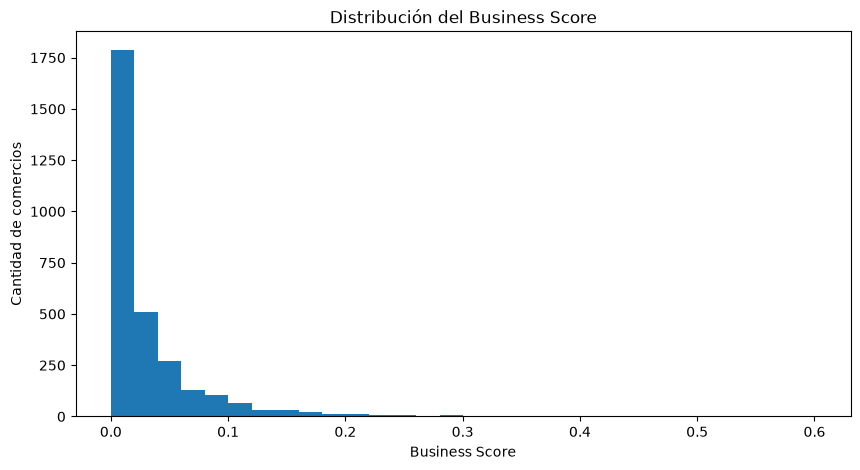

In [28]:
# ==========================================
# Histograma del Business Score
# ==========================================

plt.figure(figsize=(10,5))

plt.hist(
    segmentacion["business_score"],
    bins=30
)

plt.title("Distribución del Business Score")

plt.xlabel("Business Score")

plt.ylabel("Cantidad de comercios")

plt.show()

C:\Users\maria\AppData\Local\Temp\ipykernel_18760\3124916368.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


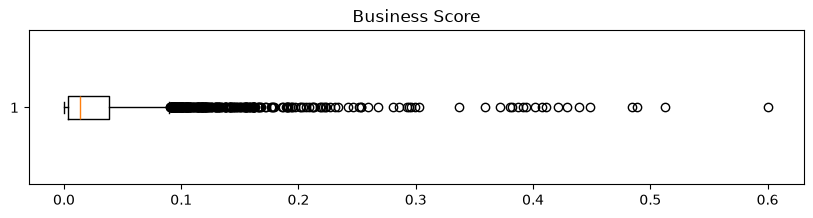

In [29]:
# ==========================================
# Boxplot del Business Score
# ==========================================

plt.figure(figsize=(10,2))

plt.boxplot(
    segmentacion["business_score"],
    vert=False
)

plt.title("Business Score")

plt.show()

##### Hallazgo 1

El Business Score presenta una distribución fuertemente asimétrica hacia la derecha.

La mayoría de los comercios obtiene puntajes bajos, mientras que un grupo reducido alcanza valores considerablemente superiores debido a su mayor frecuencia y volumen de ventas.

Esto evidencia que el valor comercial no se distribuye de manera uniforme entre todos los clientes.

##### Hallazgo 2

La mediana del Business Score (0.0136) es inferior a la media (0.0314), confirmando que un grupo reducido de comercios con alto desempeño incrementa el promedio general.

Por esta razón, la mediana representa de forma más adecuada el comportamiento típico de los comercios.

##### Hallazgo 3

El histograma muestra una alta concentración de comercios con puntajes bajos y una disminución progresiva de la frecuencia a medida que aumenta el Business Score.

Este comportamiento indica que únicamente una fracción pequeña de los comercios aporta una proporción importante del valor del negocio.

##### Hallazgo 4

Los valores extremos identificados en el boxplot corresponden a comercios con un desempeño sobresaliente y no a errores de calidad de datos.

Dado que el objetivo del negocio consiste en incrementar las comisiones provenientes de la API de pagos, estos comercios representan clientes estratégicos que deben ser priorizados dentro de las acciones comerciales y de marketing.

In [30]:
# ==========================================
# Exportar dataset base para segmentación
# ==========================================

from pathlib import Path

Path("../data/processed").mkdir(
    parents=True,
    exist_ok=True
)

segmentacion.to_excel(
    "../data/processed/segmentacion_base.xlsx",
    index=False
)

print("segmentacion_base.xlsx exportado correctamente.")

segmentacion_base.xlsx exportado correctamente.
